In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [34]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv("pima-indians-diabetes.data.csv", names=cols)
X = df.iloc[:, :-1].values.astype(float)
y = df.iloc[:, -1].values.astype(int)


In [35]:
n_samples = len(df)
print('The number of samples:', n_samples)

The number of samples: 768


In [36]:
print('Shape of Pima samples:', X.shape)

Shape of Pima samples: (768, 8)


In [ ]:
def display_pima(X, Y):
    fig, ax = plt.subplots(5, 5, figsize=(12, 10))
    fig.suptitle("Random samples from Pima dataset")

    for i in range(5):
        for j in range(5):
            ind = np.random.randint(X.shape[0])
            sample = X[ind]  

            ax[i, j].text(0.1, 0.5, str(sample), fontsize=8)
            ax[i, j].set_title(f"Label: {Y[ind]}") 
            ax[i, j].axis('off')

    plt.tight_layout()
    plt.show()

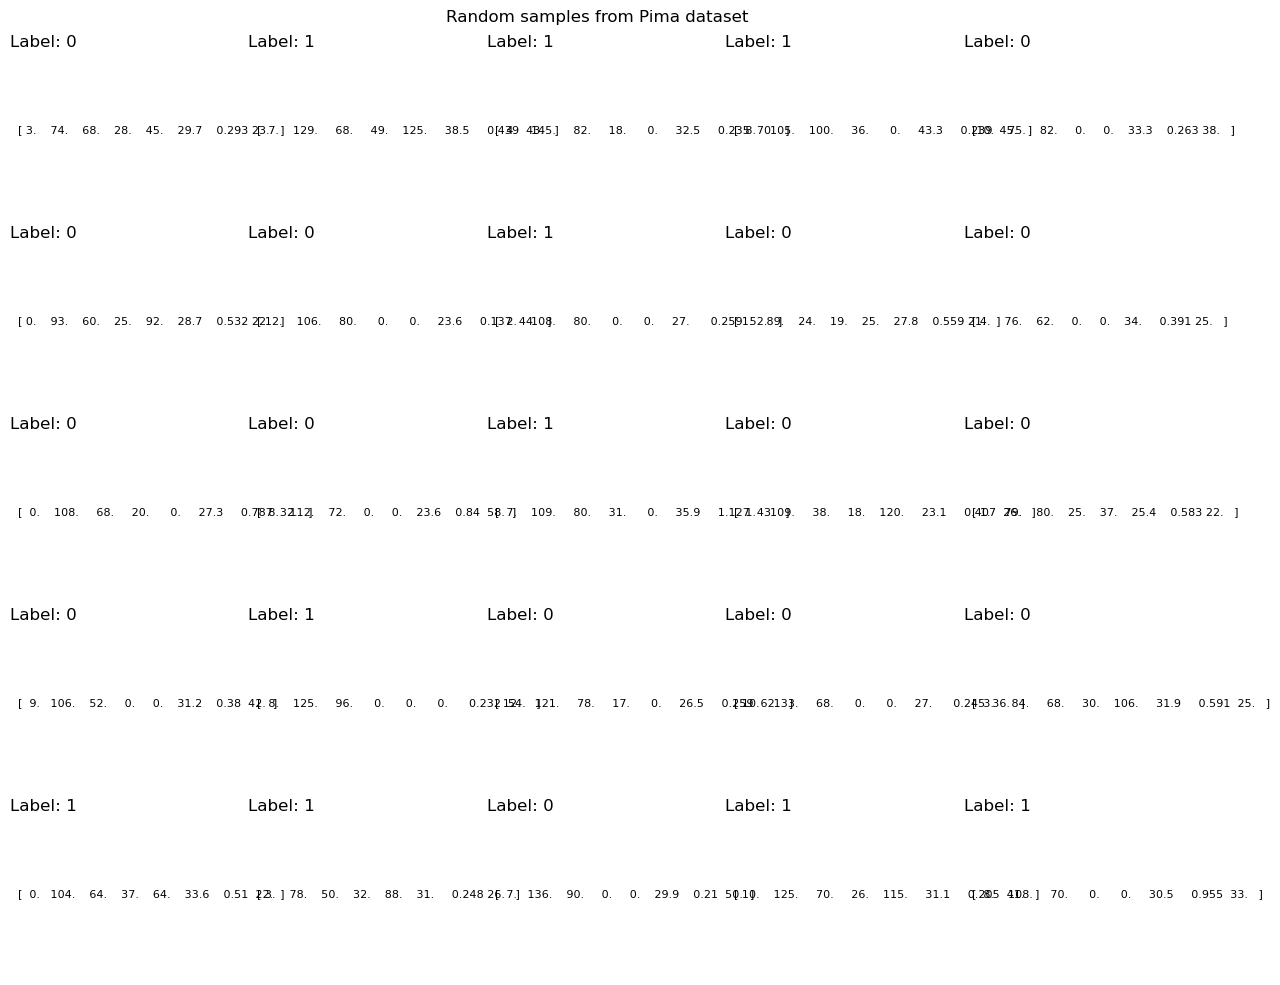

In [40]:
# Split data into 50% train and 50% test subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,      # thay digits.images
    y,      # thay digits.target
    test_size=0.2,
    random_state=200,
    shuffle=True   # đổi thành True cho Pima
)

display_pima(X_train, y_train)   # thay hàm hiển thị

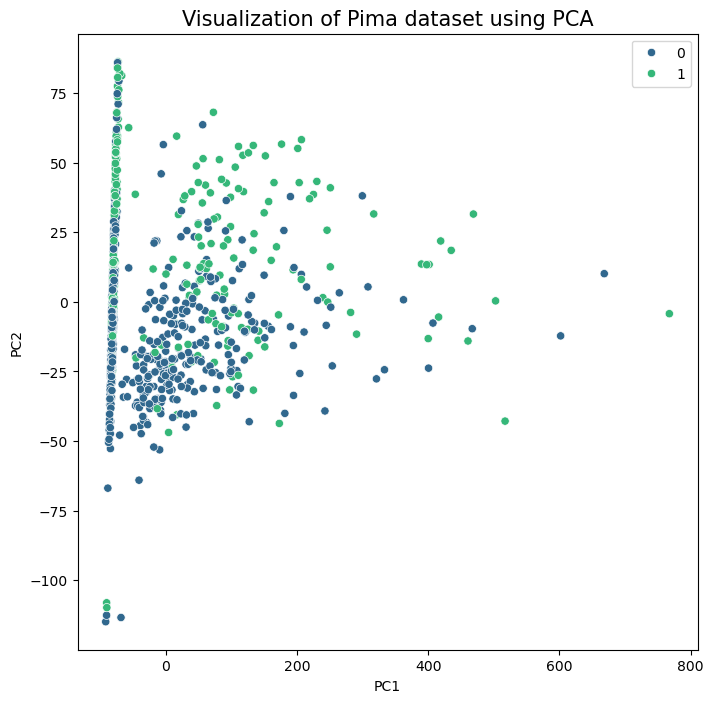

In [ ]:
from sklearn.decomposition import PCA


# Giảm chiều xuống 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X)   

# Vẽ biểu đồ
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=reduced_data[:, 0],
    y=reduced_data[:, 1],
    hue=y,                 
    palette='viridis'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualization of Pima dataset using PCA', fontsize=15)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    penalty='l2',
    fit_intercept=True,
    random_state=2021,
    solver='lbfgs',
    max_iter=500   
)

In [43]:
# Train model
clf.fit(X_train, y_train)

# Predict
predicted = clf.predict(X_test)

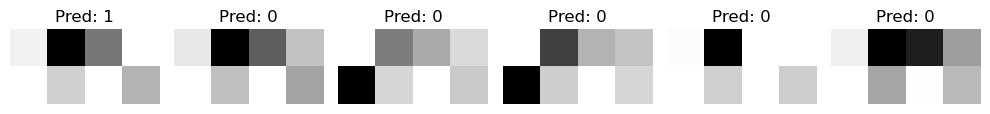

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=6, figsize=(10, 3))

for ax, sample, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = sample.reshape(2, 4)  
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_title(f'Pred: {prediction}')

plt.tight_layout()
plt.show()

In [45]:
from sklearn import metrics

print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")

Classification report for classifier LogisticRegression(max_iter=500, random_state=2021):
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       106
           1       0.76      0.65      0.70        48

    accuracy                           0.82       154
   macro avg       0.80      0.78      0.79       154
weighted avg       0.82      0.82      0.82       154




<Figure size 500x500 with 0 Axes>

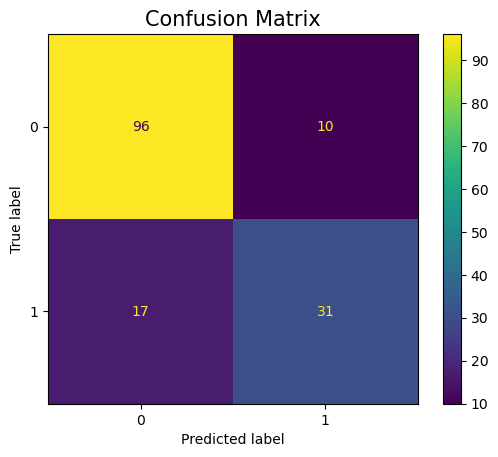

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(5, 5))

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test
)

plt.title("Confusion Matrix", fontsize=15)
plt.show()